In [2]:
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
datos_limpios= pd.read_pickle('../data/datos_arbolado')

In [4]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338991 entries, 0 to 370055
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   338991 non-null  float64
 1   lat                    338991 non-null  float64
 2   comuna                 338991 non-null  float64
 3   manzana                204681 non-null  object 
 4   calle_nombre           338991 non-null  object 
 5   calle_altura           338991 non-null  int64  
 6   calle_chapa            335639 non-null  Int32  
 7   nombre_cientifico      338991 non-null  object 
 8   ancho_acera            338991 non-null  float64
 9   estado_plantera        338842 non-null  float64
 10  ubicacion_plantera     338136 non-null  object 
 11  nivel_plantera         338324 non-null  float64
 12  diametro_altura_pecho  338991 non-null  float64
 13  altura_arbol           338991 non-null  float64
dtypes: Int32(1), float64(8), int64(1), object

In [5]:
datos_limpios=datos_limpios[datos_limpios['altura_arbol'].notna()]
datos_limpios= datos_limpios[datos_limpios['nivel_plantera'].notna()]
datos_limpios= datos_limpios[datos_limpios['estado_plantera'].notna()]

In [6]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338176 entries, 0 to 370055
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   338176 non-null  float64
 1   lat                    338176 non-null  float64
 2   comuna                 338176 non-null  float64
 3   manzana                204372 non-null  object 
 4   calle_nombre           338176 non-null  object 
 5   calle_altura           338176 non-null  int64  
 6   calle_chapa            334842 non-null  Int32  
 7   nombre_cientifico      338176 non-null  object 
 8   ancho_acera            338176 non-null  float64
 9   estado_plantera        338176 non-null  float64
 10  ubicacion_plantera     337497 non-null  object 
 11  nivel_plantera         338176 non-null  float64
 12  diametro_altura_pecho  338176 non-null  float64
 13  altura_arbol           338176 non-null  float64
dtypes: Int32(1), float64(8), int64(1), object

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer # Para rellenar nulos

# 1. Seleccionar features y limpiar nulos
features_quant = ['ancho_acera', 'diametro_altura_pecho', 'altura_arbol', 'estado_plantera', 'nivel_plantera']
df_quant = datos_limpios[features_quant].copy()

# Rellenamos los nulos de altura (el clustering no acepta nulos)
imputer = SimpleImputer(strategy='median')
df_quant_imputed = imputer.fit_transform(df_quant)

# 2. Estandarizar los datos (¡EL PASO MÁS IMPORTANTE!)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_quant_imputed)

# 3. Correr K-Means (ej. buscando 4 "tipos" de árboles)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# 4. Asignar los "tipos" de árbol de vuelta al DataFrame
datos_limpios['cluster_fenotipo'] = kmeans.labels_

# 5. Entender los clústeres
# (Invierte la escala para ver los centros en metros y cm)
centros = scaler.inverse_transform(kmeans.cluster_centers_)
df_centros = pd.DataFrame(centros, columns=features_quant)
print("Centros de los Clústeres (en unidades originales):")
print(df_centros)


Centros de los Clústeres (en unidades originales):
   ancho_acera  diametro_altura_pecho  altura_arbol  estado_plantera  \
0     4.544713              25.843322      7.099270         1.999315   
1     3.889177              60.742067     15.177343         2.006330   
2     3.865063              25.931274      7.056054         3.000000   
3     2.880556              24.195935      7.701469         1.999234   

   nivel_plantera  
0        1.128378  
1        0.984817  
2        1.428027  
3        1.094104  


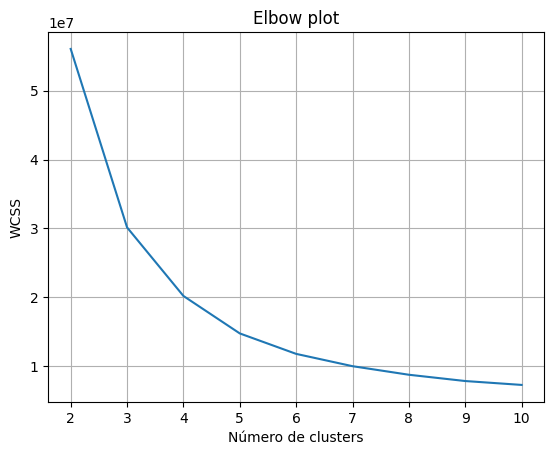

In [8]:
from sklearn.cluster import KMeans

# calculamos cada KMean para cada número de clusters, y nos quedamos con el valor
wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=10)
    kmeans.fit(df_quant)
    wcss.append(kmeans.inertia_)

# graficamos el elbow plot
plt.plot(range(2, 11), wcss)
plt.title('Elbow plot')
plt.grid("True")
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

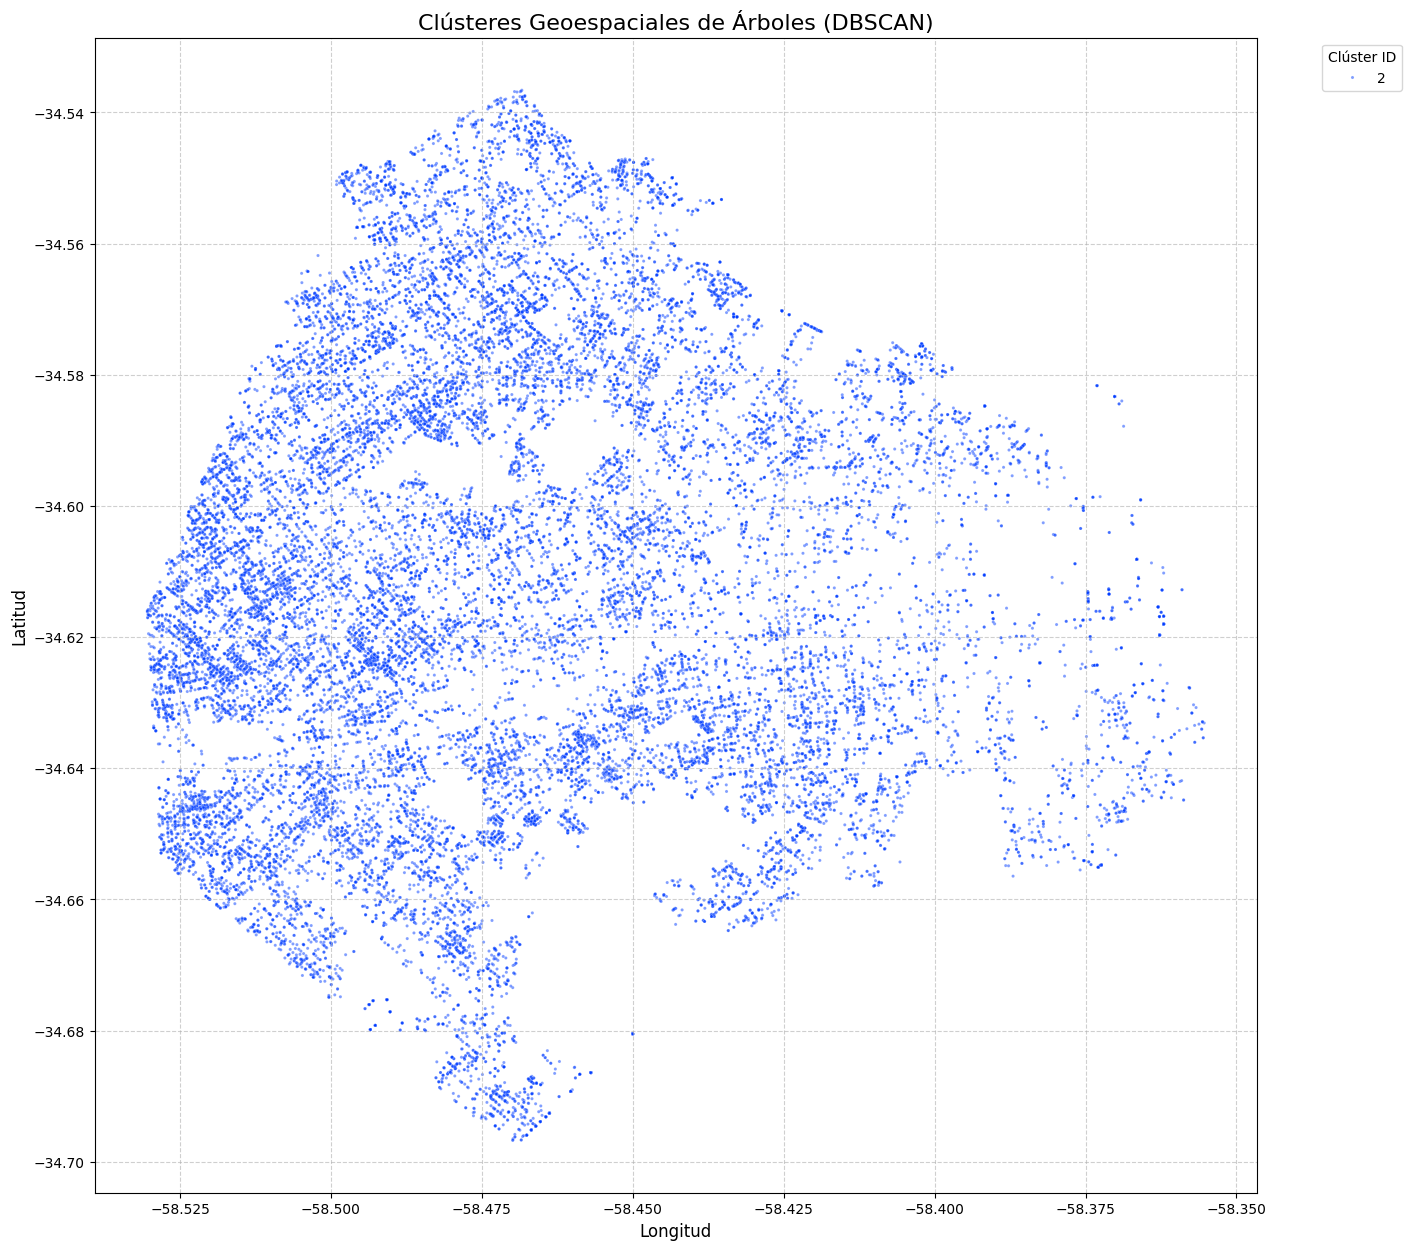

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

d= datos_limpios[datos_limpios['cluster_fenotipo']==2]

# 1. Tomamos una muestra aleatoria (ej. 50,000 puntos) para que el gráfico sea legible
# (Asumo que tu DataFrame se llama 'datos_arbolado' y ya tiene la columna 'cluster_espacial')
df_sample_geo = d.sample(n=min(32000, len(datos_limpios)), random_state=42)

# 2. Creamos el scatter plot con Seaborn
plt.figure(figsize=(15, 15))
sns.scatterplot(
    data=df_sample_geo,
    x='long',
    y='lat',
    hue='cluster_fenotipo', # ¡Aquí está la magia!
    palette='bright',         # Paleta de colores vivos
    s=5,                    # Tamaño de punto pequeño
    alpha=0.5,              # Transparencia
    legend='full'
)

plt.title('Clústeres Geoespaciales de Árboles (DBSCAN)', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(title='Clúster ID', bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
d

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol,cluster_fenotipo
33,-58.381514,-34.591928,1.0,NaN,Pellegrini Carlos,1300,13730,Otra,4.50,3.0,Regular,2.0,45.0,17.0,2
38,-58.381524,-34.592157,1.0,NaN,Pellegrini Carlos,1300,13550,Fraxinus pennsylvanica,4.50,3.0,Regular,2.0,18.0,10.0,2
62,-58.391502,-34.600499,1.0,NaN,Rodriguez Peña,700,7220,Fraxinus pennsylvanica,2.60,3.0,Regular,2.0,20.0,13.0,2
205,-58.373078,-34.624269,1.0,NaN,"Garay Juan de, Av",500,5250,Otra,3.75,3.0,Regular,1.0,5.0,2.0,2
210,-58.373536,-34.624310,1.0,NaN,"Garay Juan de, Av",500,5590,Fraxinus pennsylvanica,3.75,3.0,Regular,1.0,24.0,2.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369460,-58.469227,-34.590437,15.0,143,Punta Arenas Av.,1200,12200,Otra,3.60,3.0,Regular,1.0,22.0,11.0,2
369473,-58.469250,-34.590519,15.0,143,Punta Arenas Av.,1200,12300,Fraxinus pennsylvanica,3.60,3.0,Regular,1.0,20.0,9.0,2
369482,-58.469227,-34.590437,15.0,143,Punta Arenas Av.,1200,12200,Fraxinus pennsylvanica,3.60,3.0,Regular,1.0,20.0,9.0,2
369508,-58.469227,-34.590437,15.0,143,Punta Arenas Av.,1200,12200,Otra,3.60,3.0,Regular,1.0,20.0,10.0,2


Analisis por especies en los cluster

In [12]:
# Analicemos la composición de especies de cada clúster
conteo_especies_por_cluster = datos_limpios.groupby('cluster_fenotipo')['nombre_cientifico'].value_counts()

print(conteo_especies_por_cluster)

cluster_fenotipo  nombre_cientifico                  
0                 Fraxinus pennsylvanica                 20923
                  Otra                                    8792
                  Ligustrum lucidum f. aureovariegata     2982
                  Ficus benjamina                         2971
                  Tilia x moltkei                         2617
                                                         ...  
9                 Fraxinus americana                       740
                  Tipuana tipu                             353
                  Melia azedarach                          344
                  Platanus x acerifolia                    342
                  Acer negundo                             312
Name: count, Length: 150, dtype: int64


In [13]:
datos_limpios['cluster_fenotipo'].value_counts()


cluster_fenotipo
7    55621
4    50650
0    50099
1    41005
9    37756
3    35153
6    29428
2    23016
5    12198
8     3250
Name: count, dtype: int64

/tmp/ipykernel_6792/935672263.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'conteo'))


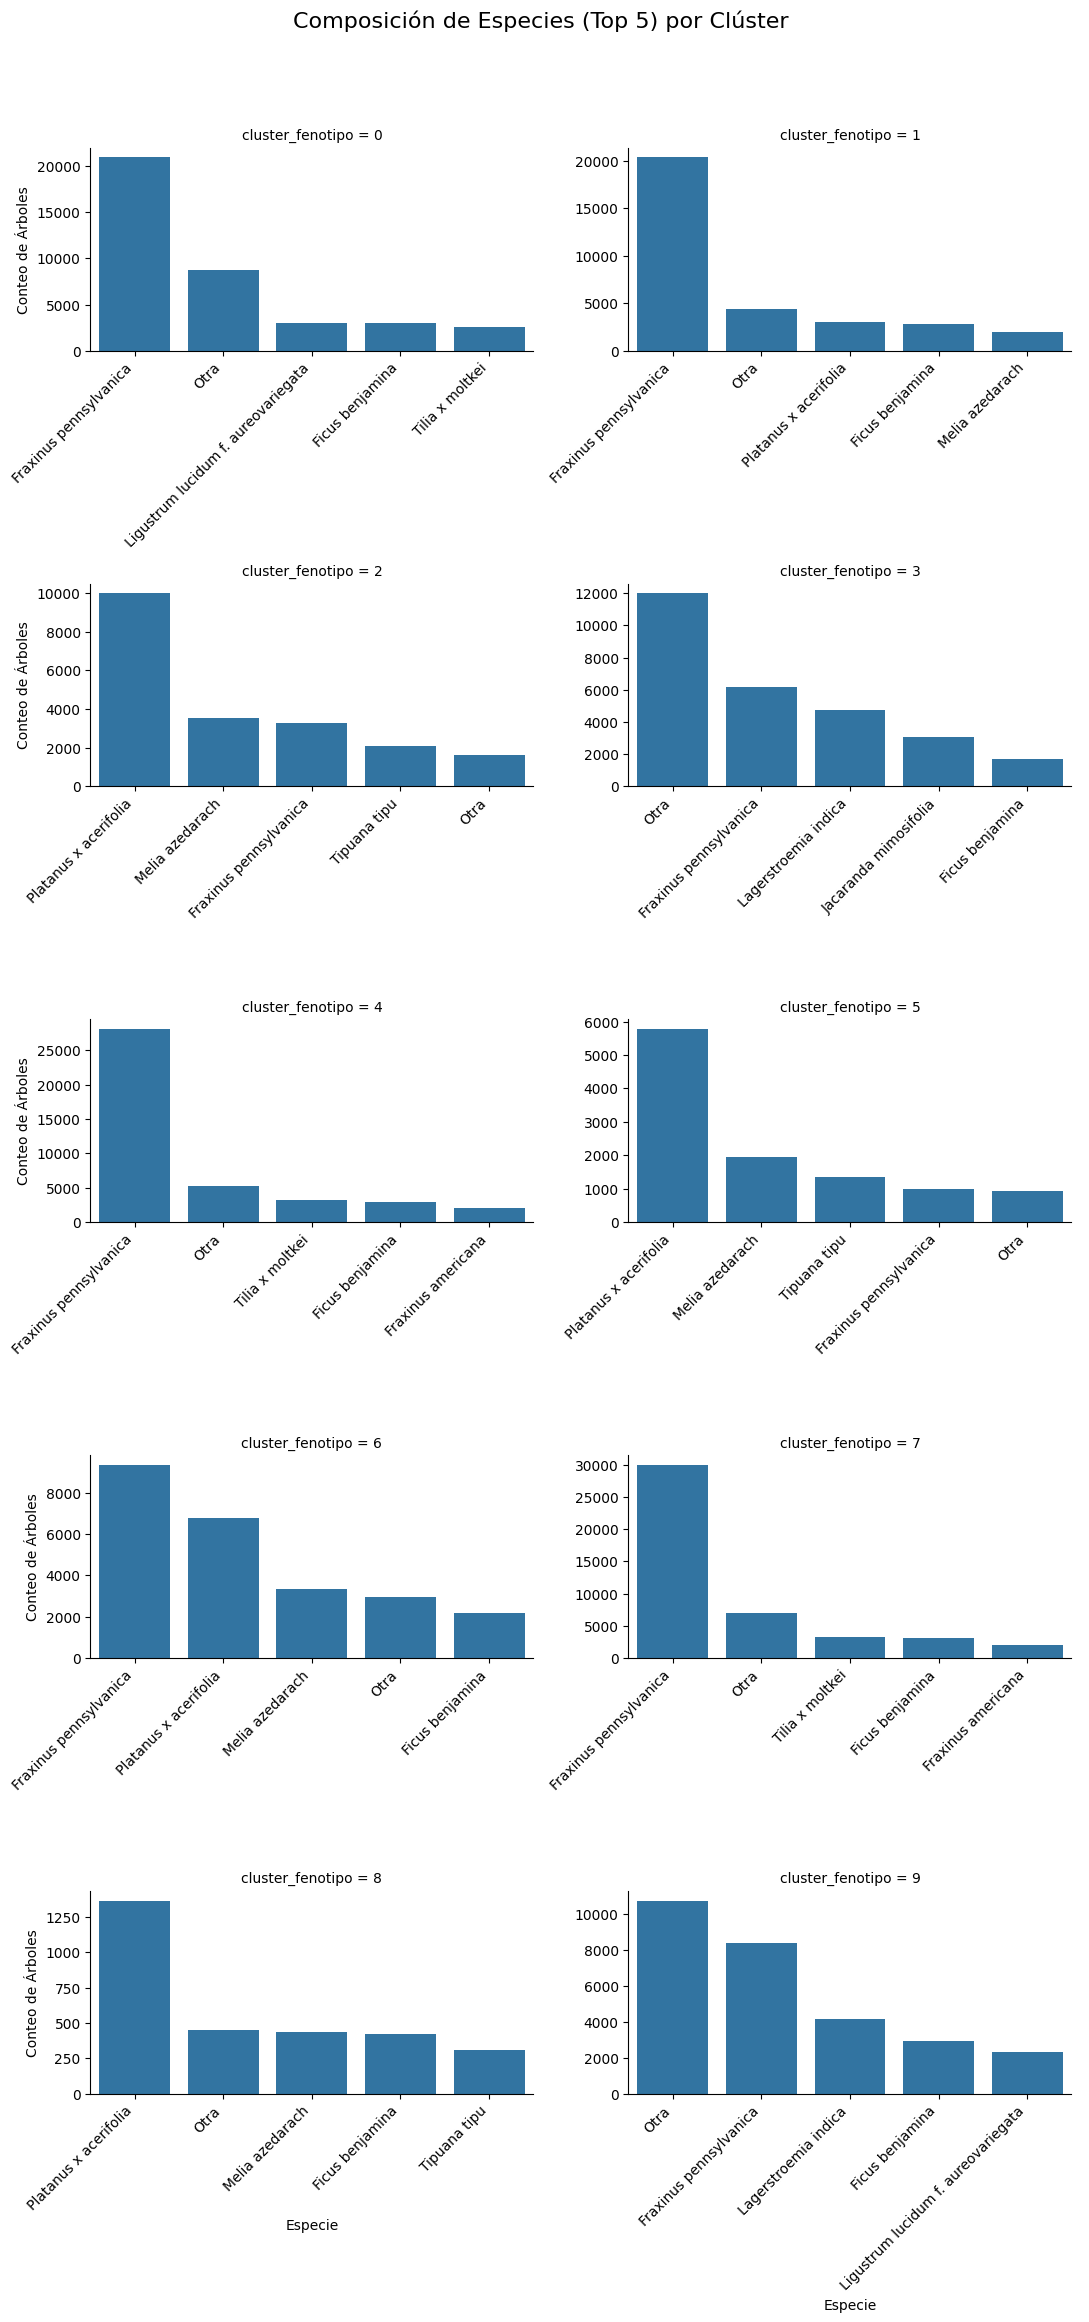

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Agrupamiento y conteo
conteo_series = datos_limpios.groupby('cluster_fenotipo')['nombre_cientifico'].value_counts()
df_conteo = conteo_series.reset_index(name='conteo')

# 2. Top 5 de especies por clúster
df_top5_por_cluster = (
    df_conteo
    .groupby('cluster_fenotipo', group_keys=False)
    .apply(lambda x: x.nlargest(5, 'conteo'))
    .reset_index(drop=True)
)

# 3. Gráfico con seaborn
g = sns.catplot(
    data=df_top5_por_cluster,
    x='nombre_cientifico',
    y='conteo',
    col='cluster_fenotipo',
    kind='bar',
    sharey=False,
    sharex=False,
    col_wrap=2,        # <-- Esto fuerza 2 columnas (2x2 en total)
    height=4.5,        # Ajusta el tamaño de cada subplot
    aspect=1.2         # Proporción ancho/alto
)

# 4. Títulos y etiquetas
g.fig.suptitle('Composición de Especies (Top 5) por Clúster', y=1.03, fontsize=16)
g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels('Especie', 'Conteo de Árboles')

plt.tight_layout()
plt.show()


* **Clúster 0: "Los Gigantes Maduros"**
    * Este clúster se define inequívocamente por su tamaño. Es el grupo de los árboles más grandes y maduros de tu dataset (probablemente los Plátanos y otras especies viejas que ya analizamos). Viven en aceras de tamaño decente, lo que les ha permitido crecer.
* **Clúster 1: "Los Privilegiados de Avenida"**
    * Este grupo es de tamaño "estándar", pero lo que lo hace único es el enorme ancho de acera del que disfruta. Estos son árboles de tamaño mediano plantados en las mejores condiciones: avenidas, bulevares o aceras muy anchas, donde tienen espacio de sobra.
* **Clúster 2: "Los Problemáticos de Plantera"**
    * Este clúster tiene un tamaño idéntico al Clúster 1, pero el algoritmo los separó por una razón: su entorno de plantación es malo. Suponiendo que números más altos son peores (ej. 3='Mala', 1.42='Muy Elevada/Rota'), este clúster identifica a los árboles de tamaño mediano que están en las planteras en peor estado.
* **Clúster 3: "Los Estresados de Vereda"**
    * El algoritmo identificó a todos los árboles de tamaño mediano que están "apretados" en las aceras más estrechas. Este es un grupo de riesgo futuro por rotura de veredas y estrés hídrico.

In [15]:
import pandas as pd
from scipy.stats import chi2_contingency
contingence_table = pd.crosstab(datos_limpios['comuna'], df['cluster_fenotipo'])
print(contingence_table)


NameError: name 'df' is not defined

In [ ]:
chi2_stat, p_value, dof, expected_frec= chi2_contingency(contingence_table)
print("--- Resultados del Test Chi-Cuadrado ---")
print(f"Estadístico Chi-Cuadrado (χ²): {chi2_stat:.4f}")
print(f"Grados de Libertad (dof): {dof}")
print(f"Valor p (p-value): {p_value:.4e}")

--- Resultados del Test Chi-Cuadrado ---
Estadístico Chi-Cuadrado (χ²): 49899.0398
Grados de Libertad (dof): 42
Valor p (p-value): 0.0000e+00
